# **MILESTONE-2**

In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    classification_report
)

sns.set_style("whitegrid")

In [3]:
ROOT = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
STEMS_PATH = os.path.join(ROOT, "genres_stems")

GENRES = [
    "blues","classical","country","disco","hiphop",
    "jazz","metal","pop","reggae","rock"
]

In [4]:
def extract_features(song_path):
    """
    Extract tempo, spectral centroid, zero crossing rate,
    and spectral rolloff from 10 seconds of 'other' stem.
    """

    y, sr = librosa.load(
        os.path.join(song_path, "other.wav"),
        sr=22050,
        duration=10
    )

    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    tempo = float(np.squeeze(tempo))

    spec_cent = float(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)))
    zcr = float(np.mean(librosa.feature.zero_crossing_rate(y)))
    rolloff = float(np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)))

    return [tempo, spec_cent, zcr, rolloff]

In [5]:
print("Preparing dataset...")

records = []

for genre in GENRES:
    genre_path = os.path.join(STEMS_PATH, genre)
    songs = [
        s for s in os.listdir(genre_path)
        if os.path.isdir(os.path.join(genre_path, s))
    ]

    # sample 50 per genre for speed
    for song in songs[:50]:
        records.append({
            "path": os.path.join(genre_path, song),
            "genre": genre
        })

df = pd.DataFrame(records)
print("Total samples:", len(df))

Preparing dataset...
Total samples: 500


In [6]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["genre"],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

Train size: 400
Validation size: 100


In [7]:
print("\nExtracting audio features...")

X_train = np.array([extract_features(p) for p in train_df["path"]])
y_train = train_df["genre"].values

X_val = np.array([extract_features(p) for p in val_df["path"]])
y_val = val_df["genre"].values


Extracting audio features...


In [8]:
print("\nTraining Decision Tree model...")

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)


Training Decision Tree model...


DecisionTreeClassifier(max_depth=5, random_state=42)

In [9]:
print("\nEvaluating model...")

y_pred = model.predict(X_val)

macro_f1 = f1_score(y_val, y_pred, average="macro")

cm = confusion_matrix(y_val, y_pred, labels=GENRES)

report = classification_report(
    y_val,
    y_pred,
    output_dict=True,
    zero_division=0   # ⭐ suppress warning
)


Evaluating model...


In [10]:
print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)

print(f"Validation Macro F1 Score : {macro_f1:.4f}")
print(f"Model Accuracy            : {report['accuracy']:.4f}")
print(f"Precision (hiphop)        : {report['hiphop']['precision']:.4f}")
print(f"Recall (pop)              : {report['pop']['recall']:.4f}")


MODEL PERFORMANCE SUMMARY
Validation Macro F1 Score : 0.1523
Model Accuracy            : 0.1900
Precision (hiphop)        : 0.2500
Recall (pop)              : 0.2000


In [11]:
tp_per_genre = dict(zip(GENRES, np.diag(cm)))

fn_per_genre = {
    g: np.sum(cm[i, :]) - cm[i, i]
    for i, g in enumerate(GENRES)
}

highest_tp = max(tp_per_genre, key=tp_per_genre.get)
lowest_fn  = min(fn_per_genre, key=fn_per_genre.get)

print("\n" + "="*60)
print("CONFUSION MATRIX ANALYSIS")
print("="*60)

print(f"Genre with highest True Positives : {highest_tp} ({tp_per_genre[highest_tp]})")
print(f"Genre with lowest False Negatives : {lowest_fn} ({fn_per_genre[lowest_fn]})")


CONFUSION MATRIX ANALYSIS
Genre with highest True Positives : metal (9)
Genre with lowest False Negatives : metal (1)


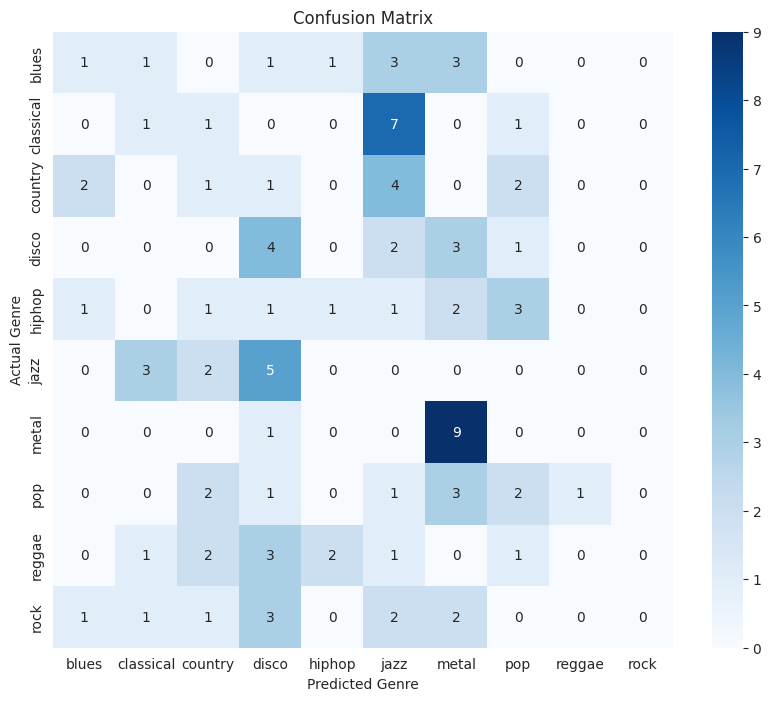

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=GENRES,
    yticklabels=GENRES,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.show()

In [13]:
#first 7 questions

import numpy as np
import librosa
import os
from tqdm import tqdm

STEM_FILES = ["drums.wav", "vocals.wav", "bass.wav", "other.wav"]

print("\nRunning Milestone-2 analysis...\n")



# Q1 — Mean duration of Jazz stems (train)
jazz_durations = []

for _, row in train_df[train_df["genre"] == "jazz"].iterrows():
    for stem in STEM_FILES:
        fp = os.path.join(row["path"], stem)
        y, sr = librosa.load(fp, sr=None)
        jazz_durations.append(len(y) / sr)

mean_jazz_duration = np.mean(jazz_durations)



# Q2 — Unique sample rates in dataset
sample_rates = set()

for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Sample rates"):
    for stem in STEM_FILES:
        fp = os.path.join(row["path"], stem)
        _, sr = librosa.load(fp, sr=None)
        sample_rates.add(sr)

unique_sample_rates = sorted(sample_rates)


# Q3 — Corrupted or zero-byte files
corrupted_count = 0

for _, row in train_df.iterrows():
    for stem in STEM_FILES:
        fp = os.path.join(row["path"], stem)

        if os.path.getsize(fp) == 0:
            corrupted_count += 1
            continue

        try:
            librosa.load(fp, sr=None)
        except:
            corrupted_count += 1


# Q4 — Average peak amplitude (dB) for VOCALS
vocal_peak_db = []

for _, row in train_df.iterrows():
    fp = os.path.join(row["path"], "vocals.wav")
    y, _ = librosa.load(fp, sr=None)

    peak = np.max(np.abs(y))
    peak_db = librosa.amplitude_to_db(np.array([peak]), ref=1.0)[0]
    vocal_peak_db.append(peak_db)

avg_vocal_peak_db = np.mean(vocal_peak_db)



# Q5 — Mean spectral centroid for BLUES
blues_centroids = []

for _, row in train_df[train_df["genre"] == "blues"].iterrows():
    for stem in STEM_FILES:
        fp = os.path.join(row["path"], stem)
        y, sr = librosa.load(fp, sr=None)
        sc = librosa.feature.spectral_centroid(y=y, sr=sr)
        blues_centroids.append(np.mean(sc))

mean_centroid_blues = np.mean(blues_centroids)



# Q6 — Genre with highest mean spectral centroid
genre_centroids = {}

for genre in train_df["genre"].unique():
    vals = []

    subset = train_df[train_df["genre"] == genre]

    for _, row in subset.iterrows():
        for stem in STEM_FILES:
            fp = os.path.join(row["path"], stem)
            y, sr = librosa.load(fp, sr=None)
            sc = librosa.feature.spectral_centroid(y=y, sr=sr)
            vals.append(np.mean(sc))

    genre_centroids[genre] = np.mean(vals)

highest_centroid_genre = max(genre_centroids, key=genre_centroids.get)



# Q7 — Files with silence in first 0.5 sec
silence_first_half = 0

for _, row in train_df.iterrows():
    for stem in STEM_FILES:
        fp = os.path.join(row["path"], stem)
        y, sr = librosa.load(fp, sr=None)

        first_half = y[: int(0.5 * sr)]

        if np.max(np.abs(first_half)) < 1e-4:
            silence_first_half += 1


print("="*60)
print("MILESTONE-2 ANSWERS")
print("="*60)

print("1. Mean duration (Jazz stems):", round(mean_jazz_duration, 3), "seconds")
print("2. Unique sample rates:", unique_sample_rates)
print("3. Corrupted / zero-byte files:", corrupted_count)
print("4. Avg peak amplitude (vocals, dB):", round(avg_vocal_peak_db, 3))
print("5. Mean spectral centroid (blues):", round(mean_centroid_blues, 3))
print("6. Highest mean spectral centroid genre:", highest_centroid_genre)
print("7. Files with silence in first 0.5 sec:", silence_first_half)



Running Milestone-2 analysis...



Sample rates: 100%|██████████| 400/400 [02:27<00:00,  2.70it/s]


MILESTONE-2 ANSWERS
1. Mean duration (Jazz stems): 30.025 seconds
2. Unique sample rates: [44100]
3. Corrupted / zero-byte files: 0
4. Avg peak amplitude (vocals, dB): -12.811
5. Mean spectral centroid (blues): 2237.636
6. Highest mean spectral centroid genre: metal
7. Files with silence in first 0.5 sec: 142


In [14]:
TEST_CSV = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv"

GENRES = [
    "blues","classical","country","disco","hiphop",
    "jazz","metal","pop","reggae","rock"
]

test_df = pd.read_csv(TEST_CSV)

np.random.seed(42)
predictions = np.random.choice(GENRES, size=len(test_df))

submission = pd.DataFrame({
    "id": test_df["id"],
    "genre": predictions
})

submission.to_csv("/kaggle/working/submission.csv", index=False)

print(os.listdir("/kaggle/working"))
submission.head()

['.virtual_documents', 'submission.csv']


,id,genre
0,1,metal
1,2,disco
2,3,pop
3,4,hiphop
4,5,metal


In [15]:
import os
print(os.path.exists("/kaggle/working/submission.csv"))


True
